In [28]:
import torch.nn as nn
import torch
from torchvision import transforms
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import glob
from torch.utils.data import Dataset, DataLoader
import cv2


device = "cuda" if torch.cuda.is_available() else "cpu"
# print(f"Using device: {device}")


In [29]:
dataset_dir = "P1_Facial_Keypoints"
imgs_path = glob.glob(dataset_dir + "/training/*.jpg")

data = pd.read_csv(dataset_dir + "/training_frames_keypoints.csv")

In [30]:
from copy import deepcopy


class FaceDataset(Dataset):
    def __init__(self, df):
        super().__init__()
        self.df = df
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    def __len__(self):
        return len(self.df)
    def __getitem__(self, index):
        img_path = "P1_Facial_Keypoints/training/" + self.df.iloc[index, 0]
        img = cv2.imread(img_path)/255
        img_cp = deepcopy(self.df.iloc[index, 1:].tolist())
        img_x = (np.array(img_cp[0::2]) / img.shape[1]).tolist()
        img_y = (np.array(img_cp[1::2]) / img.shape[0]).tolist()
        img_2d = img_x + img_y
        img_2d= torch.tensor(img_2d)
        
        img = cv2.resize(img, (224, 224))
        img = torch.tensor(img)
        img = img.permute(2, 0, 1)
        img = self.normalize(img).float()
        return img.to(device), img_2d.to(device)
    
    def load_img(self, ix):
        img_path = "P1_Facial_Keypoints/training/" + self.df.iloc[ix, 0]
        img = cv2.imread(img_path)/255
        img = img[:, :, ::-1]
        img = cv2.resize(img, (224, 224))
        return img


In [31]:
from sklearn.model_selection import train_test_split


train, test = train_test_split(data, train_size=0.8)
train_dataset = FaceDataset(train)
test_dataset = FaceDataset(test)

trn_dl = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dl = DataLoader(test_dataset, batch_size=32, shuffle=False)

# print(type(train_dataset))


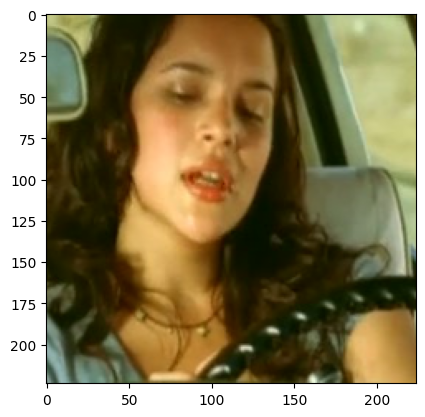

In [32]:
img = train_dataset.load_img(0)
plt.imshow(img)
plt.show()

In [33]:
from torchvision import models


model = models.vgg16(pretrained=True)
for param in model.parameters():
    param.requires_grad = False
    
model.avgpool = nn.Sequential(
    nn.Conv2d(512, 512, 3),
    nn.MaxPool2d(2, 2),
    nn.Flatten()
)
model.classifier = nn.Sequential(
    nn.Linear(in_features=2048, out_features=512),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(in_features=512, out_features=136),
    nn.Sigmoid()
)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
model.to(device)

# print(model)

d:\Anaconda\envs\exercise\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Anaconda\envs\exercise\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [38]:
def train(model, train_loader, val_loader, criterion, optimizer, epochs):
    train_losses = []
    val_losses = []
    print("Starting training...")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for ix, (images, points) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, points)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
        train_loss /= len(train_loader.dataset)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for ix, (images, points) in enumerate(val_loader):
                outputs = model(images)
                loss = criterion(outputs, points)
                val_loss += loss.item() * images.size(0)
        val_loss /= len(val_loader.dataset)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend()
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()
        

Epoch 1/50, Train Loss: 0.0408, Val Loss: 0.0291
Epoch 2/50, Train Loss: 0.0340, Val Loss: 0.0260
Epoch 3/50, Train Loss: 0.0301, Val Loss: 0.0250
Epoch 4/50, Train Loss: 0.0279, Val Loss: 0.0234
Epoch 5/50, Train Loss: 0.0259, Val Loss: 0.0231
Epoch 6/50, Train Loss: 0.0247, Val Loss: 0.0231
Epoch 7/50, Train Loss: 0.0237, Val Loss: 0.0222
Epoch 8/50, Train Loss: 0.0227, Val Loss: 0.0217
Epoch 9/50, Train Loss: 0.0219, Val Loss: 0.0222
Epoch 10/50, Train Loss: 0.0212, Val Loss: 0.0216
Epoch 11/50, Train Loss: 0.0210, Val Loss: 0.0213
Epoch 12/50, Train Loss: 0.0204, Val Loss: 0.0219
Epoch 13/50, Train Loss: 0.0198, Val Loss: 0.0213
Epoch 14/50, Train Loss: 0.0197, Val Loss: 0.0221
Epoch 15/50, Train Loss: 0.0188, Val Loss: 0.0205
Epoch 16/50, Train Loss: 0.0189, Val Loss: 0.0209
Epoch 17/50, Train Loss: 0.0185, Val Loss: 0.0208
Epoch 18/50, Train Loss: 0.0183, Val Loss: 0.0218
Epoch 19/50, Train Loss: 0.0179, Val Loss: 0.0208
Epoch 20/50, Train Loss: 0.0177, Val Loss: 0.0201
Epoch 21/

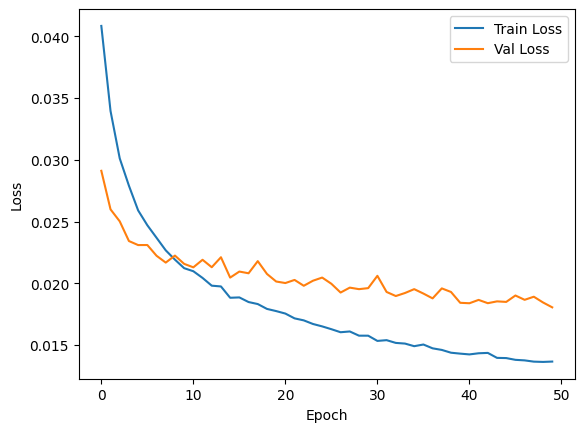

In [37]:
train(model, trn_dl, val_dl, criterion, optimizer, epochs=50)


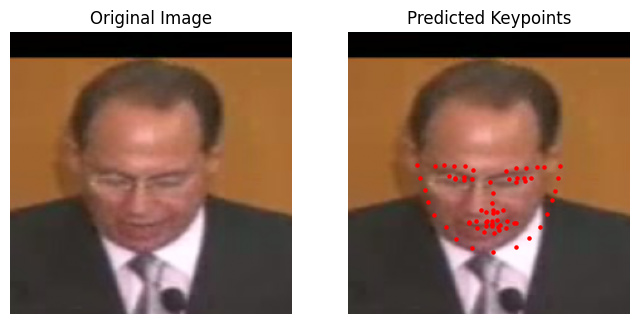

In [39]:
ix = 20
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("Original Image")
im = test_dataset.load_img(ix)
plt.imshow(im)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Predicted Keypoints")
img, points = test_dataset[ix]
plt.imshow(im)
kp = model(img[None]).flatten().detach().cpu().numpy()
plt.scatter(kp[0:68]*224, kp[68:136]*224, s=20, marker='.', c='r')
plt.axis('off')
plt.show()